In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [24]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 5, 6, 7, 8, 9, 10, 
years: 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,26,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,12.5,15.7,0.0,1,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,49,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,11.8,15.9,0.0,1,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,23,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,15.0,18.5,0.0,1,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,43,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,10.8,16.1,0.0,1,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,5,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,9.0,16.1,0.0,1,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-05-01,αττικης,αγιας βαρβαρας,26,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.109613,-0.012625,-0.187337,0.012625,0.138277,-0.005005,-0.207972,0.005005,0.029821,0.009216,0.029016,0.009216,23.35,30.49,16.21,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.3,1.6,149.9,1,2,0
1,23.82642,38.00806,2010-05-01,αττικης,αγιας παρασκευης,49,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.246119,0.081537,-0.195054,-0.081537,0.233828,0.069670,-0.201405,-0.069670,0.021948,0.017464,0.011308,0.017464,21.69,27.93,15.45,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.7,2.5,161.3,1,2,0
2,23.73031,37.93357,2010-05-01,αττικης,αγιου δημητριου,23,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124847,0.005892,-0.182192,-0.005892,0.125107,0.005422,-0.183339,-0.005422,0.009420,0.007833,0.003301,0.007833,22.48,28.45,16.51,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.1,1.3,156.6,1,2,0
3,23.71341,38.04721,2010-05-01,αττικης,αγιων αναργυρων καματερου,43,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.216806,0.029374,-0.251409,-0.029374,0.229817,0.025588,-0.262820,-0.025588,0.021876,0.009936,0.015521,0.009936,23.25,30.93,15.57,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.6,2.7,158.9,1,2,0
4,23.34009,37.69503,2010-05-01,αττικης,αγκιστριου,5,1,5,17,2010,0.201299,0.979530,0.5,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.400133,0.081147,-0.245265,-0.081147,0.406088,0.079231,-0.261955,-0.079231,0.028368,0.042376,0.058683,0.042376,17.87,20.27,15.47,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,1.2,2.4,146.4,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9604,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,1,2,1
9605,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,1,2,1
9606,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.25,25.03,13.260909,4.930000,14.068182,6.438889,21.964000,9.542308,31.713000,12.794444,0.0,6.0,295.9,1,2,1
9607,23.53320,38.08073,2018-07-16,αττικης,ελευσινας,31,16,7,29,2018,-0.101168,-0.994869,-0.5,-0.866025,-0.292057,-0.956401,36.6,29619.0,817.2,44.76554,0.100921,-0.084929,-0.150044,0.084929,0.124293,-0.052597,-0.177241,0.052597,0.043043,0.017057,0.056139,0.017057,34.64,44.

In [10]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,792,0,792,8.24%
1,2011,771,30,801,8.34%
2,2012,771,44,815,8.48%
3,2013,764,35,799,8.32%
4,2014,790,2,792,8.24%
5,2015,792,0,792,8.24%
6,2016,792,0,792,8.24%
7,2017,792,0,792,8.24%
8,2018,712,138,850,8.85%
9,2019,777,23,800,8.33%


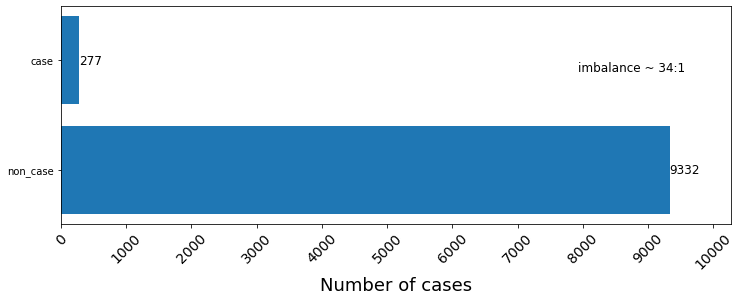

In [11]:
plot_imbalance(dataset)

In [12]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [13]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:12 || ##
Year: 2011 || w0:1, w1:13 || ##
Year: 2012 || w0:1, w1:14 || ##
Year: 2013 || w0:1, w1:14 || ##
Year: 2014 || w0:1, w1:12 || ##
Year: 2015 || w0:1, w1:12 || ##
Year: 2016 || w0:1, w1:12 || ##
Year: 2017 || w0:1, w1:12 || ##
Year: 2018 || w0:1, w1:24 || ##
Year: 2019 || w0:1, w1:13 || ##
Year: 2020 || w0:1, w1:12 || ##
Year: 2021 || w0:1, w1:12 || ##


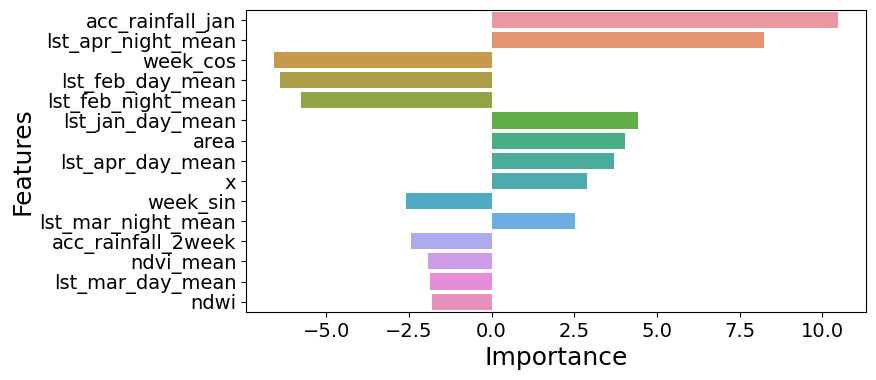

In [14]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

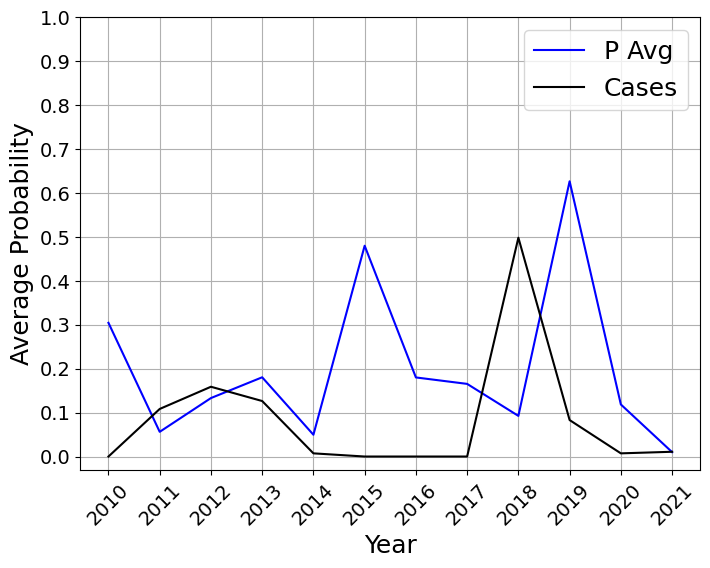

In [15]:
plot_trend_curve(results_test, list(dsc['case']))

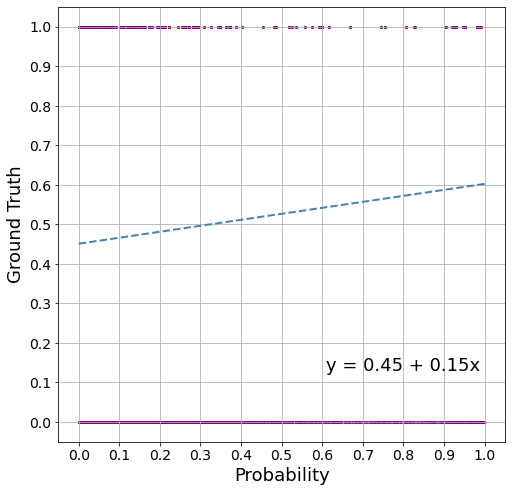

In [16]:
plot_probability_curve(results_test)

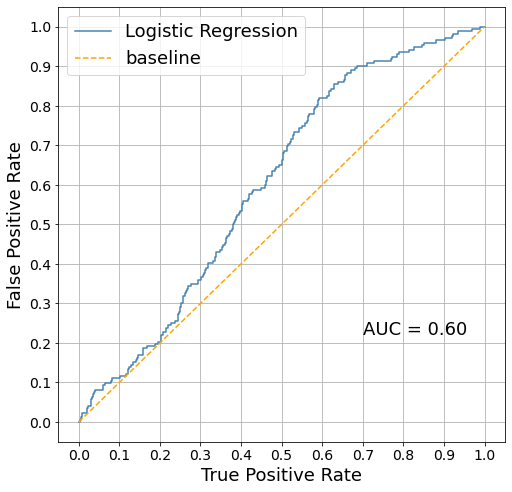

In [17]:
plot_roc_curve(results_test)

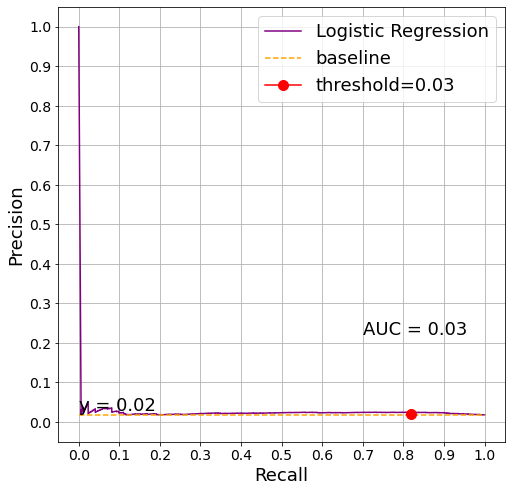

In [18]:
plot_pr_curve(results_test, plot_fbeta = True)

In [19]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

e:\Google Drive\NOA\MBD-Prediction\Greece\../Modules\utils.py:468: RuntimeWarning: invalid value encountered in longlong_scalars
  all_percentage = all_discovered/all_outof


Average: 24.72%
Weighted Average: nan%


In [20]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/05/2010,0,0,0,NaN,NaN
1,16/05/2010,0,0,0,NaN,NaN
2,01/06/2010,0,0,0,NaN,NaN
3,16/06/2010,0,0,0,NaN,NaN
4,01/07/2010,0,0,0,NaN,NaN
...,...,...,...,...,...,...
139,16/08/2021,0,0,0,NaN,NaN
140,01/09/2021,1,0,1,0.00 %,0.0
141,16/09/2021,0,0,0,NaN,NaN
142,01/10/2021,0,0,0,NaN,NaN


In [25]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,0,0,0,nan %,NaN
1,2011,21,4,21,19.05 %,0.1905
2,2012,21,1,17,5.88 %,0.0588
3,2013,28,0,23,0.00 %,0.0000
4,2014,2,1,2,50.00 %,0.5000
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,80,8,35,22.86 %,0.2286
9,2019,15,0,15,0.00 %,0.0000


In [26]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1953: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1308: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1953: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1308: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to contro

In [27]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,0.0000,0.5316,0.4684,0.0000,0.0000,0.0000,0.4785
1,2011,21.0000,0.0758,0.6078,0.1000,0.2857,0.2576,0.1397
2,2012,21.0000,0.2184,0.5346,0.0347,0.2857,0.2004,0.2397
3,2013,28.0000,0.3220,0.7033,0.0784,0.7143,0.4836,0.2943
4,2014,2.0000,0.0480,0.9772,0.0526,1.0000,0.4857,0.0555
5,2015,0.0000,0.6982,0.3018,0.0000,0.0000,0.0000,1.0239
6,2016,0.0000,0.3485,0.6515,0.0000,0.0000,0.0000,0.2367
7,2017,0.0000,0.3434,0.6566,0.0000,0.0000,0.0000,0.2138
8,2018,80.0000,0.1553,0.5249,0.1301,0.2000,0.1939,0.3809
9,2019,15.0000,0.8056,0.5651,0.0219,0.9333,0.2711,1.7081
